In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import random
from PIL import Image
from skimage.transform import resize
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from torchvision.transforms import Compose, ToTensor, Normalize, Resize

In [18]:
import os
os.chdir('/media/sslab/PACS/sslab/nguyentiendung')

In [38]:
df = pd.read_excel("data/participants.xlsx")
df_test = df[(df["No."] > 1500) & (df["No."] <= 2000)].reset_index(drop=True)
df_test

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name
0,1501,21.0,control,m,sub-BrainAge019026,INDI/SALD
1,1502,49.0,control,f,sub-BrainAge019027,INDI/SALD
2,1503,37.0,control,m,sub-BrainAge019028,INDI/SALD
3,1504,20.0,control,m,sub-BrainAge019029,INDI/SALD
4,1505,23.0,control,f,sub-BrainAge019030,INDI/SALD
...,...,...,...,...,...,...
495,1996,21.0,control,f,sub-BrainAge019533,INDI/SLIM
496,1997,22.0,control,f,sub-BrainAge019534,INDI/SLIM
497,1998,20.0,control,f,sub-BrainAge019535,INDI/SLIM
498,1999,20.0,control,f,sub-BrainAge019536,INDI/SLIM


In [40]:
test_hf_dataset = []
for _, row in df_test.iterrows():
    subj_id = row["subject_id"]
    age = row["subject_age"]
    nii_path = f"data/{subj_id}/anat/{subj_id}_T1w.nii.gz"
    test_hf_dataset.append({"image_path": nii_path, "subject_age": age})

test_hf_dataset[0:5]

[{'image_path': 'data/sub-BrainAge019026/anat/sub-BrainAge019026_T1w.nii.gz',
  'subject_age': 21.0},
 {'image_path': 'data/sub-BrainAge019027/anat/sub-BrainAge019027_T1w.nii.gz',
  'subject_age': 49.0},
 {'image_path': 'data/sub-BrainAge019028/anat/sub-BrainAge019028_T1w.nii.gz',
  'subject_age': 37.0},
 {'image_path': 'data/sub-BrainAge019029/anat/sub-BrainAge019029_T1w.nii.gz',
  'subject_age': 20.0},
 {'image_path': 'data/sub-BrainAge019030/anat/sub-BrainAge019030_T1w.nii.gz',
  'subject_age': 23.0}]

In [39]:
class BrainAgeDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
        self.target_size = (128, 128)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img_3d = nib.load(sample["image_path"]).get_fdata()

        img_3d = (img_3d - img_3d.min()) / (img_3d.max() - img_3d.min() + 1e-8)

        d, h, w = img_3d.shape
        axial = resize(img_3d[d // 2, :, :], self.target_size, mode='reflect', anti_aliasing=True)
        coronal = resize(img_3d[:, h // 2, :], self.target_size, mode='reflect', anti_aliasing=True)
        sagittal = resize(img_3d[:, :, w // 2], self.target_size, mode='reflect', anti_aliasing=True)

        img_rgb = np.stack([axial, coronal, sagittal], axis=-1)
        img_rgb = (img_rgb * 255).astype(np.uint8)

        img_pil = Image.fromarray(img_rgb)

        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = ToTensor()(img_pil)

        return {
            "image": img_tensor,
            "age": torch.tensor(sample["subject_age"], dtype=torch.float32)
        }

In [ ]:
transform = Compose([
    ToTensor(),
    Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_dataset = BrainAgeDataset(test_hf_dataset, transform=transform)
print(test_dataset[0])
len(test_dataset)

{'image': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]]), 'age': tensor(21.)}


500

In [53]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(test_loader.dataset[0])

{'image': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]]), 'age': tensor(21.)}


In [54]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.view(-1)

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
model.load_state_dict(torch.load("FL/fl-brain/global_model_final_fedprox_dirichlet.pt", map_location=device))
model.eval()

Net(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (

In [58]:
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device)
        y = batch["age"].to(device)
        y_pred = model(x)
        all_preds.extend(y_pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

preds = np.array(all_preds)
labels = np.array(all_labels)
print(preds.shape, labels.shape)

(500,) (500,)


In [119]:
# Regression Metrics
mae = mean_absolute_error(labels, preds)
mse = mean_squared_error(labels, preds)

# Accuracy within 5-year margin
acc = np.mean(np.abs(preds - labels) <= 5)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"Accuracy (±5y): {acc*100:.2f}%")

MAE: 4.39
MSE: 65.87
Accuracy (±5y): 79.00%


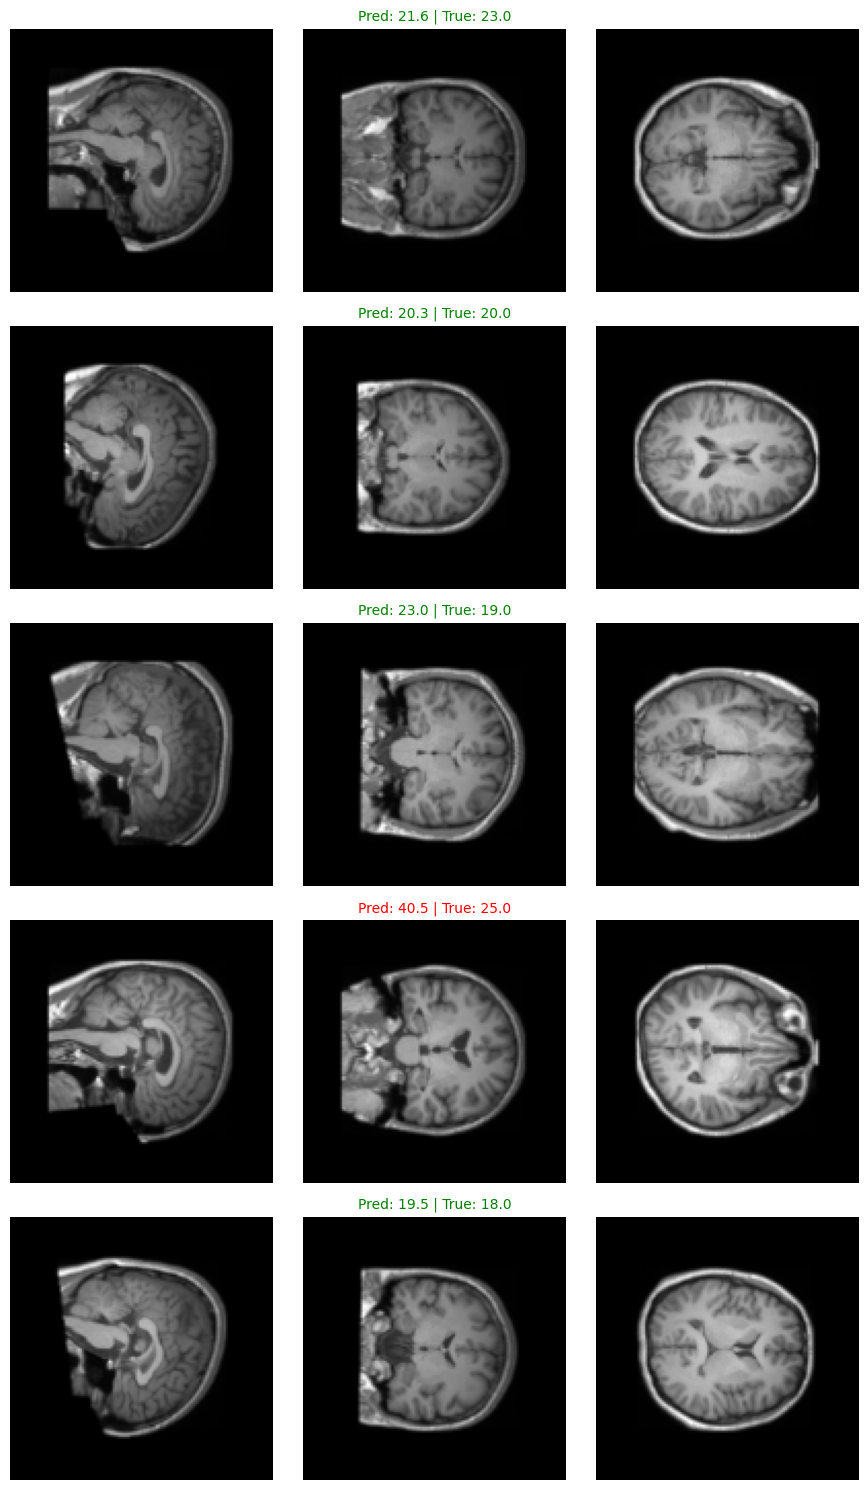

In [ ]:
samples = random.sample(list(test_dataset), 5)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(9, 15))

for row_idx, sample in enumerate(samples):
    img_tensor = sample["image"]  # shape: [3, H, W]
    true_age = sample["age"].item()

    # Chuẩn bị input cho mô hình (thêm batch dimension)
    input_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        pred_age = model(input_tensor).item()

    is_correct = abs(pred_age - true_age) <= 5
    color = "blue" if is_correct else "red"

    # Lấy từng lát cắt (kênh)
    slice_names = ['Axial', 'Coronal', 'Sagittal']
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        slice_img = img_tensor[col_idx].cpu().numpy()
        ax.imshow(slice_img, cmap="gray")
        ax.axis("off")

        if col_idx == 1:
            ax.set_title(f"Pred: {pred_age:.1f} | True: {true_age:.1f}", color=color, fontsize=10)

plt.tight_layout()
plt.show()

In [110]:
def predict_nii_file(path_nii, model, device):
    nii = nib.load(path_nii).get_fdata()
    nii = (nii - nii.min()) / (nii.max() - nii.min() + 1e-8)

    axial = nii[nii.shape[0] // 2, :, :]
    coronal = nii[:, nii.shape[1] // 2, :]
    sagittal = nii[:, :, nii.shape[2] // 2]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, slice_img in zip(axes, [axial, coronal, sagittal]):
        ax.imshow(slice_img, cmap="gray")
        ax.axis("off")
    plt.suptitle("MRI Slices")
    plt.tight_layout()
    plt.show()

    axial = resize(axial, (128, 128), mode="reflect", anti_aliasing=True)
    coronal = resize(coronal, (128, 128), mode="reflect", anti_aliasing=True)
    sagittal = resize(sagittal, (128, 128), mode="reflect", anti_aliasing=True)
    
    img_rgb = np.stack([axial, coronal, sagittal], axis=-1)
    img_rgb = (img_rgb * 255).astype(np.uint8)
    img_pil = Image.fromarray(img_rgb)

    transform = Compose([
        ToTensor(),
        Normalize([0.5] * 3, [0.5] * 3)
    ])
    img_tensor = transform(img_pil).unsqueeze(0).to(device)  # [1, 3, 128, 128]

    model.eval()
    with torch.no_grad():
        pred_age = model(img_tensor).item()

    return round(pred_age, 2)

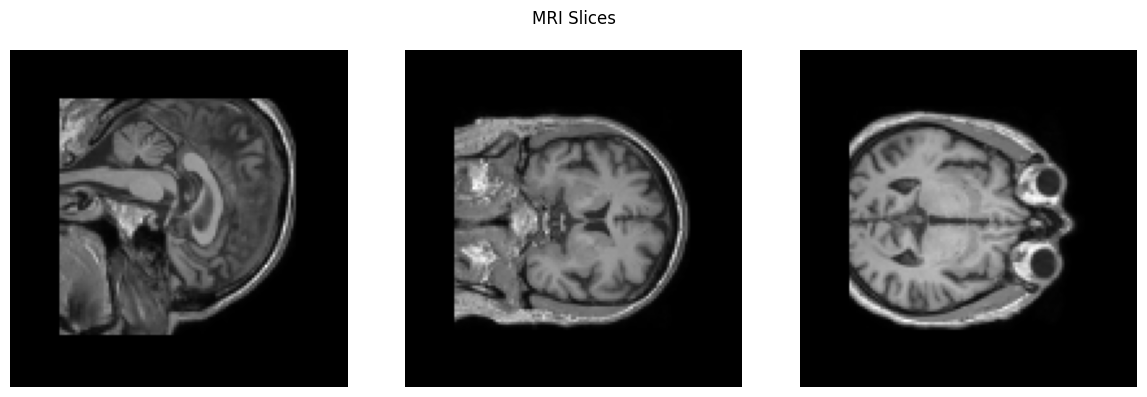


🧠 Predicted brain age: 55.45 years



In [118]:
pred_age = predict_nii_file("data/sub-BrainAge019815/anat/sub-BrainAge019815_T1w.nii.gz", model, device)
print(f"\n🧠 Predicted brain age: {pred_age} years\n")